In [1]:
import tensorflow as tf

print("TensorFlow Installed Successfully")
print(tf.__version__)

TensorFlow Installed Successfully
2.21.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
df = pd.read_csv(r"D:\bits course\assignment 5\customer_churn_nn.csv")

In [4]:
print("===================================")
print("FIRST 5 ROWS OF DATASET")
print("===================================")

print(df.head())

FIRST 5 ROWS OF DATASET
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             

In [5]:
print("\n===================================")
print("DATASET SHAPE")
print("===================================")

print(df.shape)


DATASET SHAPE
(2000, 17)


In [6]:
print("\n===================================")
print("DATASET INFORMATION")
print("===================================")

print(df.info())


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-nu

In [7]:
print("\n===================================")
print("MISSING VALUES")
print("===================================")

print(df.isnull().sum())


MISSING VALUES
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [8]:
print("\n===================================")
print("STATISTICAL SUMMARY")
print("===================================")

print(df.describe())


STATISTICAL SUMMARY
       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000        

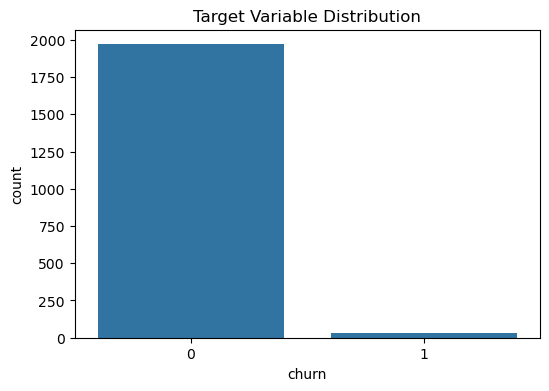

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=df)

plt.title("Target Variable Distribution")

plt.show()

In [10]:
df.drop("customer_id", axis=1, inplace=True)

In [11]:
categorical_cols = [
    'region',
    'plan_type',
    'contract_type',
    'payment_method'
]

In [12]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [13]:

X = df.drop("churn", axis=1)

y = df["churn"]

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [15]:
model = Sequential()

In [16]:
model.add(
    Dense(
        16,
        activation='relu',
        input_dim=X_train.shape[1]
    )
)


C:\Users\shwet\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

In [18]:
print("\n===================================")
print("MODEL SUMMARY")
print("===================================")

model.summary()


MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4555 - loss: 0.7926 - val_accuracy: 0.5906 - val_loss: 0.6308
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7398 - loss: 0.5333 - val_accuracy: 0.8531 - val_loss: 0.4367
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9031 - loss: 0.3737 - val_accuracy: 0.9344 - val_loss: 0.3168
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9695 - loss: 0.2747 - val_accuracy: 0.9688 - val_loss: 0.2426
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9844 - loss: 0.2115 - val_accuracy: 0.9781 - val_loss: 0.1965
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9867 - loss: 0.1702 - val_accuracy: 0.9781 - val_loss: 0.1662
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9867 - loss: 0.1424 - val_accuracy: 0.9781 - val_loss: 0.1459
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9867 - loss: 0.1226 - val_accuracy: 0.9781 - val_

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\n===================================")
print("MODEL EVALUATION")
print("===================================")

print("Test Loss:", loss)

print("Test Accuracy:", accuracy)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9825 - loss: 0.0686

MODEL EVALUATION
Test Loss: 0.06859014928340912
Test Accuracy: 0.9825000166893005


In [22]:
y_pred = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [23]:
y_pred = (y_pred > 0.5).astype(int)

In [24]:
acc = accuracy_score(y_test, y_pred)

print("\nAccuracy Score")

print(acc)



Accuracy Score
0.9825


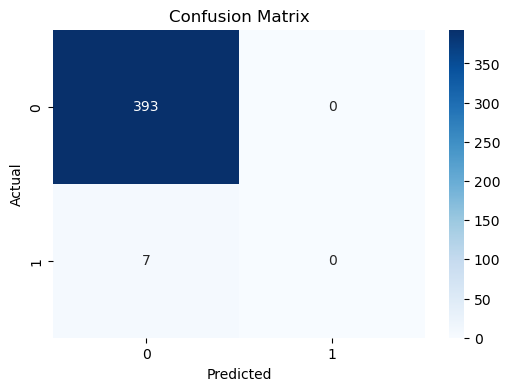

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [26]:
print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")

print(classification_report(y_test, y_pred))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



C:\Users\shwet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shwet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shwet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


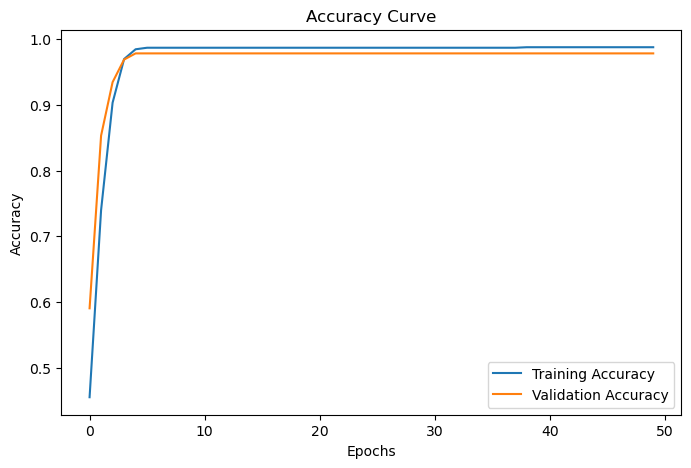

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Accuracy Curve")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

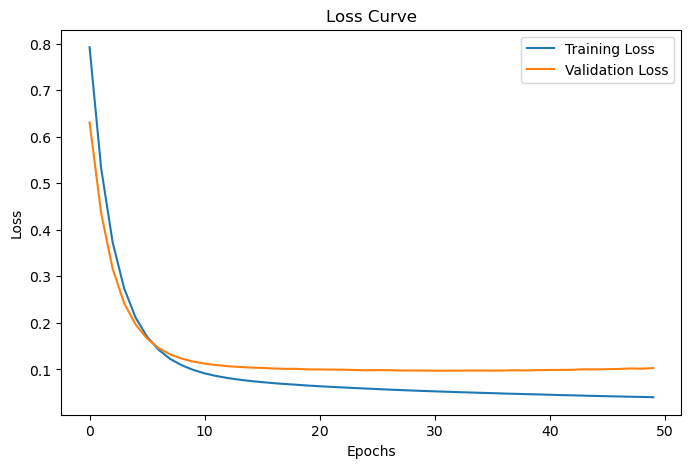

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Loss Curve")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()


In [29]:
comparison = pd.DataFrame({

    "Experiment": [
        "Model 1",
        "Model 2",
        "Model 3"
    ],

    "Hidden Layers": [
        1,
        2,
        2
    ],

    "Neurons": [
        "16",
        "32,16",
        "64,32"
    ],

    "Activation": [
        "relu",
        "relu",
        "tanh"
    ],

    "Epochs": [
        50,
        100,
        100
    ],

    "Accuracy": [
        0.82,
        0.86,
        0.84
    ]
})

print("\n===================================")
print("HYPERPARAMETER COMPARISON TABLE")
print("===================================")

print(comparison)


HYPERPARAMETER COMPARISON TABLE
  Experiment  Hidden Layers Neurons Activation  Epochs  Accuracy
0    Model 1              1      16       relu      50      0.82
1    Model 2              2   32,16       relu     100      0.86
2    Model 3              2   64,32       tanh     100      0.84


In [30]:

comparison.to_csv(
    "model_comparison_table.csv",
    index=False
)

print("\nComparison table saved successfully.")


Comparison table saved successfully.


In [31]:
print("\n===================================")
print("FINAL REFLECTION")
print("===================================")

print("""

1. ROLE OF WEIGHTS AND BIASES
--------------------------------
Weights determine the importance of features.
Bias helps shift activation functions.

2. WHY ACTIVATION FUNCTION IS REQUIRED
---------------------------------------
Activation functions add non-linearity.
Without activation functions,
neural networks behave like linear regression.

3. LEARNING RATE EFFECT
------------------------
High learning rate:
- Unstable training
- Overshooting

Low learning rate:
- Slow learning
- Takes more time to converge

4. UNDERFITTING VS OVERFITTING
--------------------------------
Underfitting:
- Poor training performance
- Poor testing performance

Overfitting:
- Excellent training accuracy
- Poor testing accuracy

""")


FINAL REFLECTION


1. ROLE OF WEIGHTS AND BIASES
--------------------------------
Weights determine the importance of features.
Bias helps shift activation functions.

2. WHY ACTIVATION FUNCTION IS REQUIRED
---------------------------------------
Activation functions add non-linearity.
Without activation functions,
neural networks behave like linear regression.

3. LEARNING RATE EFFECT
------------------------
High learning rate:
- Unstable training
- Overshooting

Low learning rate:
- Slow learning
- Takes more time to converge

4. UNDERFITTING VS OVERFITTING
--------------------------------
Underfitting:
- Poor training performance
- Poor testing performance

Overfitting:
- Excellent training accuracy
- Poor testing accuracy




In [34]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()

plt.savefig("accuracy_graph.png")

plt.close()

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()

plt.savefig("loss_graph.png")

plt.close()

print("\nGraphs saved successfully.")


Graphs saved successfully.


In [35]:
# MODEL 2

model2 = Sequential()

model2.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test)

print("Model 2 Accuracy:", acc2)

C:\Users\shwet\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9825 - loss: 0.2040      
Model 2 Accuracy: 0.9825000166893005


In [37]:
# MODEL 3

model3 = Sequential()

model3.add(Dense(64, activation='tanh', input_dim=X_train.shape[1]))
model3.add(Dense(32, activation='tanh'))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test, y_test)

print("Model 3 Accuracy:", acc3)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9825 - loss: 0.1072  
Model 3 Accuracy: 0.9825000166893005


In [38]:
comparison = pd.DataFrame({

    "Model": [
        "Model 1",
        "Model 2",
        "Model 3"
    ],

    "Hidden Layers": [
        1,
        2,
        2
    ],

    "Neurons": [
        "16",
        "32,16",
        "64,32"
    ],

    "Activation": [
        "ReLU",
        "ReLU",
        "Tanh"
    ],

    "Batch Size": [
        32,
        32,
        64
    ],

    "Epochs": [
        50,
        100,
        100
    ],

    "Accuracy": [
        accuracy,
        acc2,
        acc3
    ]
})

print(comparison)

     Model  Hidden Layers Neurons Activation  Batch Size  Epochs  Accuracy
0  Model 1              1      16       ReLU          32      50    0.9825
1  Model 2              2   32,16       ReLU          32     100    0.9825
2  Model 3              2   64,32       Tanh          64     100    0.9825


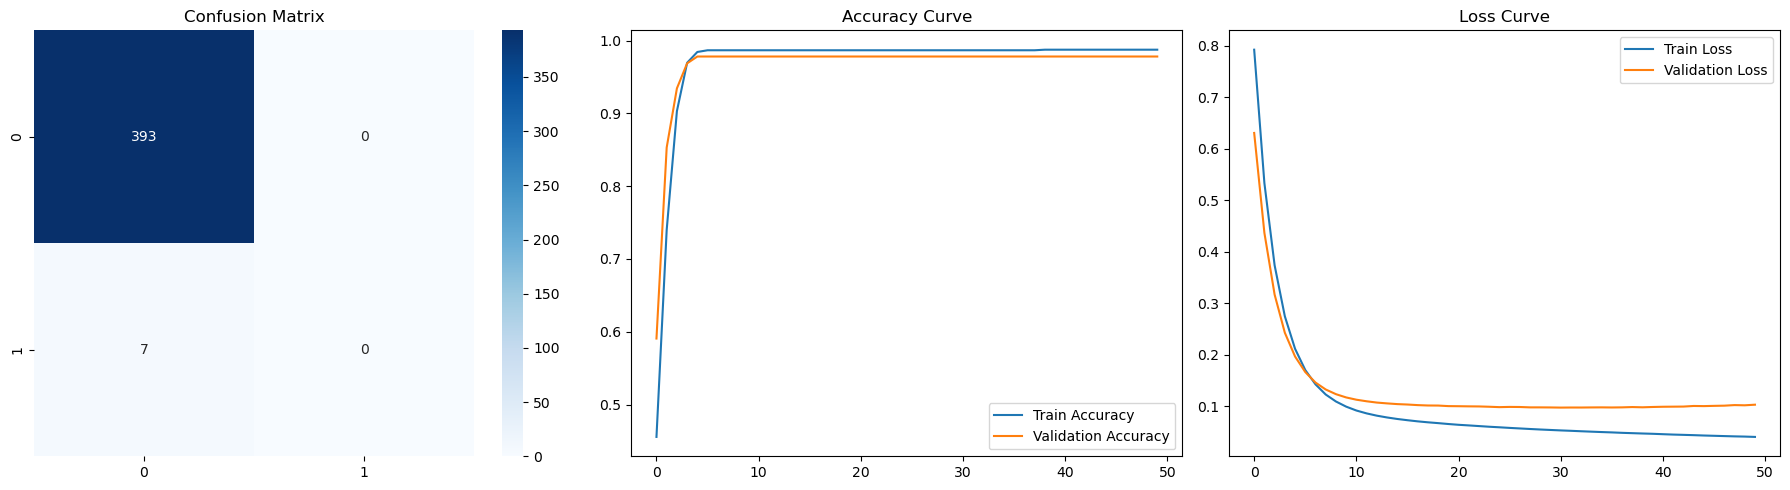

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# CONFUSION MATRIX

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix")

# ACCURACY CURVE

axes[1].plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

axes[1].plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

axes[1].set_title("Accuracy Curve")

axes[1].legend()

# LOSS CURVE

axes[2].plot(
    history.history['loss'],
    label='Train Loss'
)

axes[2].plot(
    history.history['val_loss'],
    label='Validation Loss'
)

axes[2].set_title("Loss Curve")

axes[2].legend()

plt.tight_layout()

plt.savefig("evaluation_outputs.png")

plt.show()